In [36]:
import numpy as np
import pymcel as pc

In [37]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [38]:
sistema = [
    dict(m=1,r=[0,0,0],v=[0,0,0]),
    dict(m=1,r=[-1,0,0],v=[0,1,0.5]),
    dict(m=0.1,r=[1,0,0],v=[0,-0.1,0.0])
]

In [39]:
ts = np.linspace(0, 5, 1000)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

Energía cinetica

In [40]:
K = 0
for i in range(3):
    K += 0.5 * sistema[i]['m'] * (vs[i,0,0]**2 + vs[i,0,1]**2 + vs[i,0,2]**2)**0.5
print(K)

0.5640169943749475


Energía potencial

In [41]:
G = 1
U = 0
for i in range(3):
    for j in range(3):
        if i != j:
            U += -G * sistema[i]['m'] * sistema[j]['m'] / ((rs[i,0,0] - rs[j,0,0])**2 + (rs[i,0,1] - rs[j,0,1])**2 + (rs[i,0,2] - rs[j,0,2])**2)**0.5
U = U/2
print(U)

-1.15


In [42]:
E = K + U
print(E)

-0.5859830056250525


In [43]:
# Create animation of the three bodies' trajectories
fig = go.Figure()

# Add traces for each body at different time points
colors = ['red', 'blue', 'green']
names = ['Body 1', 'Body 2', 'Body 3']

for i in range(3):
    fig.add_trace(go.Scatter3d(
        x=rs[i, :, 0],
        y=rs[i, :, 1],
        z=rs[i, :, 2],
        mode='lines',
        name=names[i],
        line=dict(color=colors[i], width=2)
    ))

# Add initial positions as markers
for i in range(3):
    fig.add_trace(go.Scatter3d(
        x=[rs[i, 0, 0]],
        y=[rs[i, 0, 1]],
        z=[rs[i, 0, 2]],
        mode='markers',
        name=f'{names[i]} start',
        marker=dict(size=8, color=colors[i]),
        showlegend=False
    ))

fig.update_layout(
    title='Three Body Problem Trajectories',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    width=900,
    height=900
)

fig.show()

In [44]:
Is = 0
Gs = 0
for i in range(3):
    Is += sistema[i]["m"] * np.linalg.norm(rps[i,:,:], axis=1)**2
    Gs += sistema[i]["m"] * np.sum(rps[i,:,:] * vps[i,:,:], axis=1)

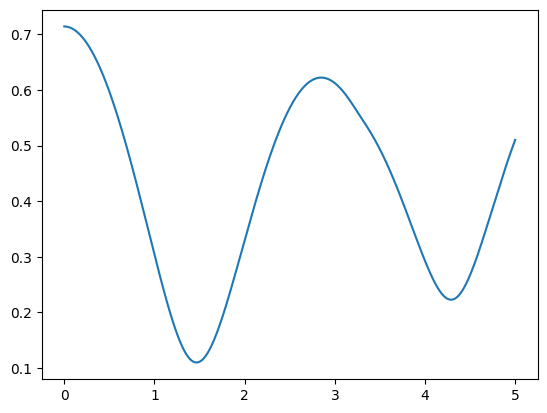

In [45]:
plt.plot(ts,Is)

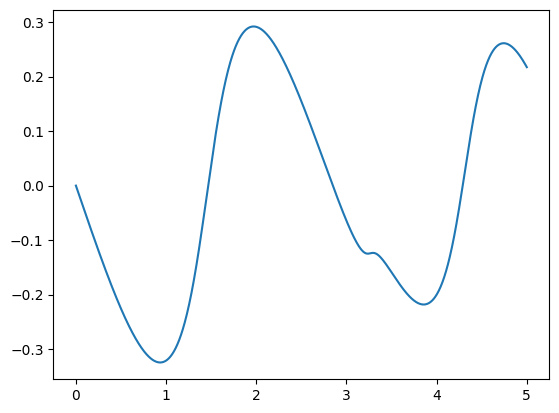

In [46]:
plt.plot(ts,Gs)